## Fourier Transform Foundations

### This notebook is the first step to build simple foundational examples in Fourier-optics examples 

The purpose is deliberately simple:

1. create a 2D circular aperture in real space;
2. compute its 2D Fourier transform;
3. plot the real-space aperture, Fourier amplitude, and Fourier phase;
4. make the coordinate and FFT-shift conventions explicit.

This is the base layer for everything that follows: angular-spectrum propagation, Fresnel propagation, digital holography, ER/HIO phase retrieval, and ptychography.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


### Fourier functions

In [2]:
def F2d(u):
    """Centered, unitary 2D Fourier transform."""
    return np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(u)))

def iF2d(u):
    """Centered, unitary 2D Fourier transform."""
    return np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(u)))

### Spatial grid

In [3]:

# Number of pixels along x and y.
N = 128

# Physical field of view. The units are arbitrary here.
L = 2.0

# Pixel pitch / sample spacing in real space.
dx = L / N

# Centered coordinate vector:
# [-L/2, -L/2 + dx, ..., L/2 - dx]
x = (np.arange(N) - N / 2) * dx

# 2D coordinate grids.
# X contains the x-coordinate of every pixel.
# Y contains the y-coordinate of every pixel.
X, Y = np.meshgrid(x, x, indexing="xy")

# Radial coordinate measured from the center.
R = np.sqrt(X**2 + Y**2)

### Circular aperture

In [4]:
# Radius of the aperture in the same physical units as x and y.
radius = 0.3

# Binary aperture. The comparison R < radius gives True/False.
# astype(float) converts True -> 1.0 and False -> 0.0.
aperture = (R < radius).astype(float)

# Fourier transform of the aperture
F_aperture = F2d(aperture)

### Plotting the aperture and its fourier transform

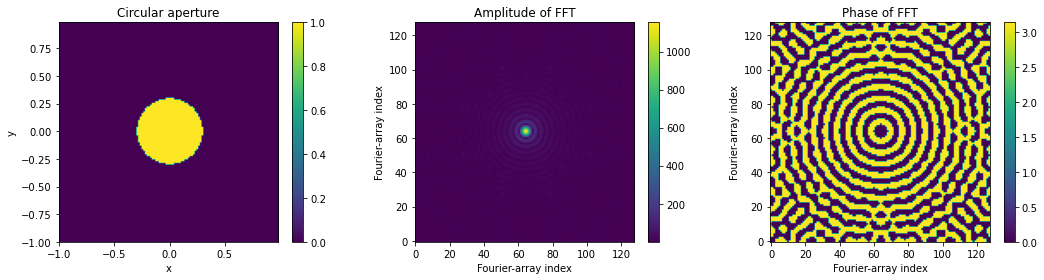

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# extent makes Matplotlib label the image axes using physical coordinates.
extent_real = [x[0], x[-1], x[0], x[-1]]

im0 = axes[0].imshow(aperture, extent=extent_real, origin="lower")
axes[0].set_title("Circular aperture")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_aspect("equal")
fig.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(np.abs(F_aperture), origin="lower")
axes[1].set_title("Amplitude of FFT")
axes[1].set_xlabel("Fourier-array index")
axes[1].set_ylabel("Fourier-array index")
axes[1].set_aspect("equal")
fig.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(np.angle(F_aperture), origin="lower")
axes[2].set_title("Phase of FFT")
axes[2].set_xlabel("Fourier-array index")
axes[2].set_ylabel("Fourier-array index")
axes[2].set_aspect("equal")
fig.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()


### Frequency axis construction

In [6]:
# Frequency coordinates in cycles per physical unit.
# np.fft.fftfreq returns the FFT-frequency ordering.
# np.fft.fftshift moves negative frequencies to the left and positive to the right.
fx = np.fft.fftshift(np.fft.fftfreq(N, d=dx))
fy = np.fft.fftshift(np.fft.fftfreq(N, d=dx))
FX, FY = np.meshgrid(fx, fy, indexing="xy")

print(f"Frequency spacing df = {fx[1] - fx[0]:.3f}")
print(f"Expected df = 1/L = {1/L:.3f}")
print(f"Min frequency = {fx[0]:.3f}")
print(f"Max frequency = {fx[-1]:.3f}")

Frequency spacing df = 0.500
Expected df = 1/L = 0.500
Min frequency = -32.000
Max frequency = 31.500


### Plotting with physical frequency axes

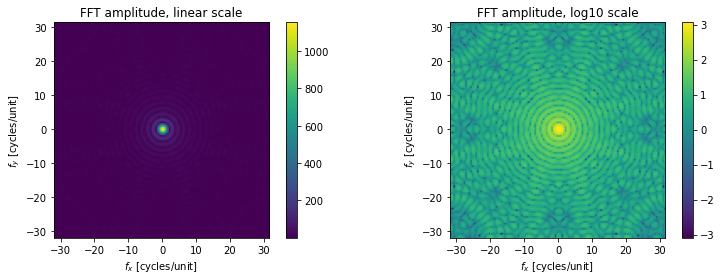

In [7]:
extent_freq = [fx[0], fx[-1], fy[0], fy[-1]]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

im0 = axes[0].imshow(np.abs(F_aperture), extent=extent_freq, origin="lower")
axes[0].set_title("FFT amplitude, linear scale")
axes[0].set_xlabel("$f_x$ [cycles/unit]")
axes[0].set_ylabel("$f_y$ [cycles/unit]")
axes[0].set_aspect("equal")
fig.colorbar(im0, ax=axes[0], fraction=0.046)

# Add a small value before log to avoid log(0).
im1 = axes[1].imshow(np.log10(np.abs(F_aperture) + 1e-9), extent=extent_freq, origin="lower")
axes[1].set_title("FFT amplitude, log10 scale")
axes[1].set_xlabel("$f_x$ [cycles/unit]")
axes[1].set_ylabel("$f_y$ [cycles/unit]")
axes[1].set_aspect("equal")
fig.colorbar(im1, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()

### Check with inverse fourier 

In [8]:
aperture_reconstructed = iF2d(F_aperture)

# The result should be real, but numerical roundoff may create tiny imaginary values.
max_abs_error = np.max(np.abs(aperture_reconstructed - aperture))

print(f"Max absolute reconstruction error: {max_abs_error:.3e}")


Max absolute reconstruction error: 4.475e-16
